# Module 4 Homework: Chapter 5

## Ryan Waterman 
## 7/31/25

In [42]:
#Import the ISLP package to retreive the data
from ISLP import load_data
from ISLP.models import summarize, ModelSpec as MS, poly
from sklearn.base import clone
from functools import partial
import statsmodels.api as sm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Problem 6

We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your analysis.

In [44]:
# Set the seed
seed = 42
rng = np.random.default_rng(seed)

### Part A

Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors.

In [33]:
default = load_data('Default')
default.head(5)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [34]:
default['default'].replace({'Yes':1, 'No':0}, inplace=True)

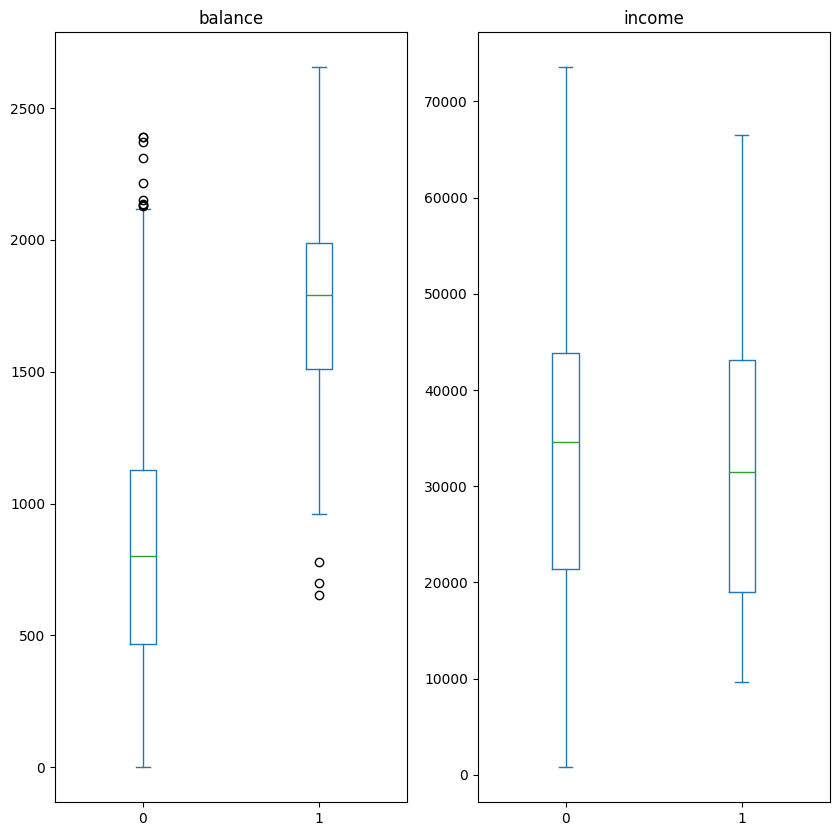

In [35]:
default.plot.box('default', figsize = (10,10));

In [36]:
X = default[['income', 'balance']]
y = default[['default']]

glm = sm.GLM(y,X).fit()

In [37]:
summarize(glm)

,coef,std err,z,P>|z|
income,-0.000001,7.470000e-08,-15.991,0.0
balance,0.000097,2.790000e-06,34.771,0.0


**Both income and balance have statistically significant predictive relationship with 'default', with a P>|z| equal to 0. The standard error for each predictor is low relative to the coefficient (a factor of e-2 for each variable), indicating that the estimate is precise.**

### Part B

Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model.

**I was struggling to understand how this is supposed to be implemented... Below are some notes on the bootstrap:**

1. Used to quantify uncertainty associated with an estimator (or learning method).
2. Can be used to assess variability of coefficient estimates and predictions from a statistical learning method (applicable here).
3. The 'partial' function is used to freeze the model and response in the bootstrap process, as they are to be unchanged throughout all iterations.
4. The model is cloned to repeatedly copy the model formula so it can be refit to the new, randomly sampled data.
5. boot_fn is the function that will be wrapped by the partial function to freeze the model and response, take in the new D and idx values, then return the intercept and slopes of the variables.

In [48]:
def boot_fn(model_matrix, response, D, idx):
    D_ = D.loc[idx]
    Y_ = D_[response]
    X_ = clone(model_matrix).fit_transform(D_)
    return sm.OLS(Y_, X_).fit().params


In [49]:
glm_func = partial(boot_fn, MS(['income', 'balance']), 'default')

In [53]:
np.array([glm_func(default,
            rng.choice(400,
            400,
            replace=True)) for _ in range(1000)])

array([[-1.01095412e-01, -2.99647078e-08,  1.57639113e-04],
       [-3.73060988e-02, -3.10770953e-07,  7.99161033e-05],
       [-3.11313280e-02, -7.78850063e-07,  9.76541839e-05],
       ...,
       [-4.13752889e-02, -9.35918336e-07,  1.23459657e-04],
       [-1.63992175e-01,  1.74725415e-06,  1.68353829e-04],
       [-1.30370294e-01,  6.19543381e-07,  1.84555835e-04]],
      shape=(1000, 3))

**The returned array represents the intercept, as well as the bootstrap estimate slope for the 'income' and 'balance' predictors. These values are based on randomly sampled observations within the default dataset for each boostrap iteration.** 

### Part C

Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance.

**Similar to part B, this was difficult to parse. The notes, below, helped me to grasp the implementation and functionality of the standard error estimate from boot_fn.**

1. The alpha function outputs the alpha estimate by applying the minimum variance formula (seen below) to the observations, indexed by idx. 

    ![img](min_var.png)

2. The cumulative standard error of the bootstrap estimates can be comupted using the formula, below:

    ![img](boot_se.png)

3. The bootstrap method is a way to empirically emulate the variance in the data, which is a step beyond formulaically computing the statistical outputs for a model or dataset.

In [ ]:
def alpha_func(D, X, response, idx):
    cov_ = np.cov(D[[X,response]].loc[idx], rowvar=False)
    return ((cov_[1,1] - cov_[0,1]) /
            (cov_[0,0]+cov_[1,1]-2*cov_[0,1]))

In [58]:
income_se = alpha_func(default, 'income', 'default', range(len(default)))
balance_se = alpha_func(default, 'balance', 'default', range(len(default)))

print(income_se, balance_se)

2.6752630268808885e-07 -0.00012976827606560925


In [68]:
def boot_SE(func, D, X, response, n=None, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0] 
    for _ in range(B):
        idx = rng.choice(D.index,
        n,
        replace=True)

        # Print the indices to ensure the same are actually selected each time this function is called.
        if _ < 5:
            print(idx[0])

        value = func(D, X, response, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)

**This function was modified to accomodate one X variable at a time, as the default df does not match the dimensions from the lab. The first five indices are also printed as a means for me to visually ensure the same indices are selected for each loop iteration every time the function is called.**

In [69]:
alpha_se_income = boot_SE(alpha_func, default, 'income', 'default', seed=seed)

892
3386
341
2317
9001


In [70]:
alpha_se_balance = boot_SE(alpha_func, default, 'balance', 'default', seed=seed)

892
3386
341
2317
9001


**Great, as expected, the first five indices match. The intent of seeding this function is to always return the same indices, but I wanted additional verification that this functioned as intended.**

In [71]:
print(alpha_se_income, alpha_se_balance)

1.3901158718828967e-07 6.736478821680249e-06


### Part D

Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.

**The order of magnitude of the standard errors are similar. The bootstrap SE computation was relatively involved, so this is a good indication to me that there is not an error in my computation process. Digging deeper into each of the respective standard error outputs:**

- **GLM Standard Errors:**
    - **income: 7.470000e-08**
    - **balance: 2.790000e-06**

- **Bootstrap Standard Errors:**
    - **income: 1.3901158718828967e-07**
    - **balance: 6.736478821680249e-06**

**The bootstrap estimate for standard error is greater than the GLM estimated standard error for both variables. The bootstrap approach is an empirical measure of the model standard error, computed, in this case, with 1000 resampling iterations. The GLM standard error is a formulaic approach to understanding the model standard error. In this case, the formulaic approach estimates less variability in the data than the empirical approach, indicating the model might not fit the data well. Other factors that may influence this are outliers or heteroscedasticity, which the bootstrap approach may periodically filter out across the sampling iterations.**

## Problem 9

We will now consider the Boston housing data set, from the ISLP library.

### Part A

Based on this data set, provide an estimate for the population mean of medv. Call this estimate ˆμ.

In [72]:
boston = load_data('Boston')

**The sample mean is an estimate of the population mean, so this will be used for part A.**

In [87]:
mew_hat = boston['medv'].mean()
mew_hat

np.float64(22.532806324110677)

### Part B

Provide an estimate of the standard error of ˆμ. Interpret this result.

*Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.*

**Compute the standard deviation of the sample.**

In [76]:
sample_stdev = boston['medv'].std()

**Standard error is computed with the following equation:**

![img](se_eq.png)

In [86]:
SE = sample_stdev/(len(boston['medv'])**0.5)
SE

np.float64(0.40886114749753505)

**This value (0.40886) represents the expected dispersion from the population mean for many random samples of the same size.**

### Part C

Now estimate the standard error of ˆμ using the bootstrap. How does this compare to your answer from (b)?

In [126]:
from sklearn.utils import resample

**The resample function from sklearn will be used to do the resampling for bootstrap estimation of the standard error.**

In [132]:
stds = []
means = []

for j in range(10):
    for i in range(10000):
        sample = resample(boston['medv'])
        means.append(np.mean(sample))

    stds.append(np.std(means, ddof=1))

**Now that the resampled means have been aggregated across 10000 bootstrap iterations 10 times, compute the mean standard error accross the distribution.**

In [133]:
mean_bootstrap_se = np.mean(stds)
mean_bootstrap_se

np.float64(0.40674568022787394)

In [134]:
se_delta = (1 - (mean_bootstrap_se/SE))*100
se_delta

np.float64(0.5174048164294898)

**The bootstrap standard error, sampled a total of 100000 times, is 0.52% smaller than the sample standard error. Ultimately, the sample standard error is an accurate estimate of the population standard error, which is what the bootstrap standard error emulates.**

### Part D

Based on your bootstrap estimate from (c), provide a 95% confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9). 

*Hint: You can approximate a 95% confidence interval using the formula [ˆμ −2SE(ˆμ), ˆμ + 2SE(ˆμ)].*

**Use the two standard error rule to compute the 95% CI**

In [ ]:
lower_bound = mew_hat - (2*mean_bootstrap_se)
upper_bound = mew_hat + (2*mean_bootstrap_se)

print(f"""The 95% CI for mean medv (median value of owner-occupied homes in $1000s), 
      computed with the bootstrap method is [{lower_bound}, {upper_bound}].""")

The 95% CI for mean medv (median value of owner-occupied homes in $1000s), 
      computed with the bootstrap method is [21.71931496365493, 23.346297684566423]


In [165]:
std_lower_bound = mew_hat - (2*SE)
std_upper_bound = mew_hat + (2*SE)

print(f"""The 95% CI for mean medv (median value of owner-occupied homes in $1000s), 
      computed with the sample stdev is [{std_lower_bound}, {std_upper_bound}].""")

The 95% CI for mean medv (median value of owner-occupied homes in $1000s), 
      computed with the sample stdev is [22.496642222024274, 22.56897042619708].


In [168]:
range_delta = (upper_bound - lower_bound)/(std_upper_bound-std_lower_bound)
range_delta

np.float64(22.49444375840341)

**The 95% CI means that if the population were repeatedly sampled from and a 95% CI were calculated for each sample, 95% of the calculated intervals would contain the true population parameter. Comparing the results between the bootstrap and std, it is clear the bootstrap method accounts for more variance, as the 95% CI range is 22.49 times larger than the 95% CI from the std method.**

### Part E

Based on this data set, provide an estimate, ˆμ<sub>med</sub>, for the median value of medv in the population.

In [144]:
mew_med = boston['medv'].median()
mew_med

np.float64(21.2)

### Part F

We now would like to estimate the standard error of ˆμmed. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.

In [147]:
stds = []
meds = []

for j in range(10):
    for i in range(10000):
        sample = resample(boston['medv'])
        meds.append(np.median(sample))

    stds.append(np.std(meds, ddof=1))

In [148]:
med_bootstrap_se = np.mean(stds)
med_bootstrap_se

np.float64(0.37998352452144923)

**The estimated standard error of the median for boston['medv'] is 0.38 (on this run), which is less than the estimated standard error of the mean (0.4067 on the latest run). The similarity in the median and mean values indicates that the distribution of medv is normal with minimal skew. To test this theory, I will create a histogram plot.**

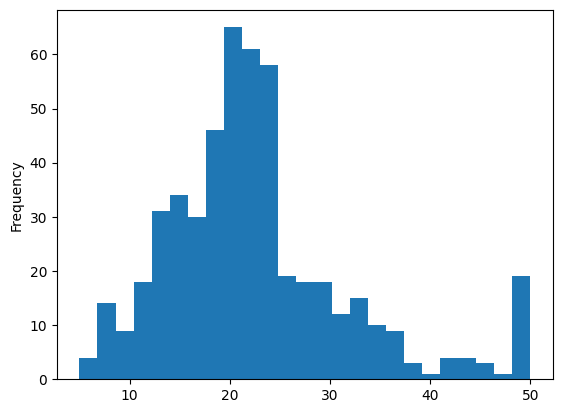

In [151]:
boston['medv'].plot.hist(bins=25);

**There does appear to be some skew in this dataset, so my assumption was incorrect. The next assumption I could make is that the median values are tightly distributed, so resampling does not influence the median value as often as it does for the mean, which is more heavily weighted by the extremes in the dataset.**

### Part G

Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity ˆμ0.1. (You can use the np.percentile() function.)

In [153]:
mew_0_1 = np.percentile(boston['medv'], 10)
mew_0_1

np.float64(12.75)

### Part H

Use the bootstrap to estimate the standard error of ˆμ0.1. Comment on your findings.

In [154]:
stds = []
perc_10 = []

for j in range(10):
    for i in range(10000):
        sample = resample(boston['medv'])
        perc_10.append(np.percentile(sample, 10))

    stds.append(np.std(perc_10, ddof=1))

perc_10_bootstrap_se = np.mean(stds)
perc_10_bootstrap_se

np.float64(0.5006003852775375)

**The standard error of the medv 10th percentile is 0.5 based on 100000 boostrap iterations. This is the largest standard error of the evaluated statistical methods, indicating that there is more variance at the extremes of the dataset. Based on the histogram, above, this is visually evident as well.**